# Detector binario óptimo mediante una red MLP

**Objetivo:** entrenar una red neuronal MLP para estimar $P(Y=1\mid X=x)$ sin entregarle las probabilidades de generación, medias ni varianzas reales. El sistema estima esos parámetros a partir de datos, selecciona el umbral de decisión usando validación y evalúa sobre muestras independientes.

Se calculan explícitamente:

- $P(\hat Y=0\mid Y=1)$: se envió un 1 y se detectó un 0.
- $P(\hat Y=1\mid Y=0)$: se envió un 0 y se detectó un 1.
- $P_e=P(Y=0)P(\hat Y=1\mid Y=0)+P(Y=1)P(\hat Y=0\mid Y=1)$.

La MLP se implementa desde cero con NumPy para observar claramente su funcionamiento.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.grid': True, 'grid.alpha': 0.25})

SEED = 42
rng = np.random.default_rng(SEED)

# Caso exigente: ambas clases tienen la misma media, pero diferente varianza.
# La decisión MAP necesita dos fronteras sobre X; un único umbral de amplitud no basta.
P1_REAL = 0.40
MU0_REAL, SIGMA0_REAL = 0.0, 0.65
MU1_REAL, SIGMA1_REAL = 0.0, 2.00

N_TRAIN, N_VAL, N_TEST = 30000, 10000, 30000

print('Configuración real usada únicamente para generar datos:')
print(f'P(Y=0)={1-P1_REAL:.3f}, P(Y=1)={P1_REAL:.3f}')
print(f'Clase 0: media={MU0_REAL:.3f}, varianza={SIGMA0_REAL**2:.3f}')
print(f'Clase 1: media={MU1_REAL:.3f}, varianza={SIGMA1_REAL**2:.3f}')

Configuración real usada únicamente para generar datos:
P(Y=0)=0.600, P(Y=1)=0.400
Clase 0: media=0.000, varianza=0.423
Clase 1: media=0.000, varianza=4.000


## 1. Generación independiente de datos

Para cada observación primero se genera la etiqueta $Y$ según su probabilidad real y después se genera:

$$X\mid Y=k\sim\mathcal{N}(\mu_k,\sigma_k^2).$$

Entrenamiento, validación y prueba usan semillas y muestras distintas. La prueba permanece intacta hasta la evaluación final.

In [ ]:
def generar_datos(n, semilla):
    local_rng = np.random.default_rng(semilla)
    y = (local_rng.random(n) < P1_REAL).astype(np.float64)
    medias = np.where(y == 0, MU0_REAL, MU1_REAL)
    sigmas = np.where(y == 0, SIGMA0_REAL, SIGMA1_REAL)
    x = medias + sigmas * local_rng.standard_normal(n)
    return x.reshape(-1, 1), y.reshape(-1, 1)

X_train, y_train = generar_datos(N_TRAIN, 101)
X_val, y_val = generar_datos(N_VAL, 202)
X_test, y_test = generar_datos(N_TEST, 303)

print('Tamaños:', X_train.shape, X_val.shape, X_test.shape)
print('Proporción observada de unos:')
print(f'  entrenamiento={y_train.mean():.4f}, validación={y_val.mean():.4f}, prueba={y_test.mean():.4f}')

Tamaños: (30000, 1) (10000, 1) (30000, 1)
Proporción observada de unos:
  entrenamiento=0.3975, validación=0.3922, prueba=0.4041


## 2. Estimación de probabilidades, medias, varianzas y ruido

Las cantidades reales no serán utilizadas por la MLP. Se estiman exclusivamente con el conjunto de entrenamiento.

In [ ]:
def estimar_parametros(x, y):
    x = x.ravel(); y = y.ravel().astype(int)
    resultado = {}
    for k in (0, 1):
        valores = x[y == k]
        resultado[k] = {
            'prior': len(valores) / len(x),
            'media': valores.mean(),
            'varianza': valores.var(ddof=1),
            'desviacion': valores.std(ddof=1),
            'n': len(valores)
        }
    return resultado

estimados = estimar_parametros(X_train, y_train)
for k in (0, 1):
    e = estimados[k]
    print(f'Clase {k}: P={e["prior"]:.4f}, media={e["media"]:.4f}, '
          f'varianza={e["varianza"]:.4f}, sigma={e["desviacion"]:.4f}, n={e["n"]}')

# La estandarización se ajusta solamente con entrenamiento.
media_x, std_x = X_train.mean(axis=0), X_train.std(axis=0)
normalizar = lambda x: (x - media_x) / std_x
Z_train, Z_val, Z_test = map(normalizar, (X_train, X_val, X_test))

Clase 0: P=0.6025, media=-0.0029, varianza=0.4218, sigma=0.6495, n=18074
Clase 1: P=0.3975, media=0.0150, varianza=4.0661, sigma=2.0164, n=11926


## 3. MLP implementada desde cero

Arquitectura utilizada:

$$1\rightarrow32\rightarrow32\rightarrow16\rightarrow1.$$

Las capas ocultas utilizan `tanh`; la salida utiliza una sigmoide y representa una estimación de $P(Y=1\mid X=x)$. El entrenamiento minimiza entropía cruzada binaria mediante Adam y detención temprana.

In [ ]:
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def bce(y, p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return float(-np.mean(y * np.log(p) + (1-y) * np.log(1-p)))

class MLPBinaria:
    def __init__(self, capas=(1, 32, 32, 16, 1), semilla=42):
        r = np.random.default_rng(semilla)
        self.W = [r.normal(0, np.sqrt(1/a), size=(a, b)) for a, b in zip(capas[:-1], capas[1:])]
        self.b = [np.zeros((1, b)) for b in capas[1:]]
        self.mW = [np.zeros_like(w) for w in self.W]; self.vW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]; self.vb = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def forward(self, X):
        activaciones = [X]
        for W, b in zip(self.W[:-1], self.b[:-1]):
            activaciones.append(np.tanh(activaciones[-1] @ W + b))
        activaciones.append(sigmoid(activaciones[-1] @ self.W[-1] + self.b[-1]))
        return activaciones

    def predict_proba(self, X):
        return self.forward(X)[-1]

    def paso(self, X, y, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        A = self.forward(X)
        n = len(X)
        dZ = (A[-1] - y) / n
        gW, gb = [None]*len(self.W), [None]*len(self.b)
        for i in range(len(self.W)-1, -1, -1):
            gW[i] = A[i].T @ dZ
            gb[i] = dZ.sum(axis=0, keepdims=True)
            if i > 0:
                dA = dZ @ self.W[i].T
                dZ = dA * (1 - A[i]**2)

        self.t += 1
        for i in range(len(self.W)):
            self.mW[i] = beta1*self.mW[i] + (1-beta1)*gW[i]
            self.vW[i] = beta2*self.vW[i] + (1-beta2)*(gW[i]**2)
            self.mb[i] = beta1*self.mb[i] + (1-beta1)*gb[i]
            self.vb[i] = beta2*self.vb[i] + (1-beta2)*(gb[i]**2)
            mWh = self.mW[i]/(1-beta1**self.t); vWh = self.vW[i]/(1-beta2**self.t)
            mbh = self.mb[i]/(1-beta1**self.t); vbh = self.vb[i]/(1-beta2**self.t)
            self.W[i] -= lr*mWh/(np.sqrt(vWh)+eps)
            self.b[i] -= lr*mbh/(np.sqrt(vbh)+eps)

    def copiar_parametros(self):
        return ([w.copy() for w in self.W], [b.copy() for b in self.b])

    def cargar_parametros(self, estado):
        self.W, self.b = ([w.copy() for w in estado[0]], [b.copy() for b in estado[1]])

def entrenar(modelo, Xtr, ytr, Xv, yv, epocas=300, lote=256, lr=2e-3, paciencia=30):
    historial = {'train': [], 'val': []}
    mejor, mejor_estado, espera = np.inf, None, 0
    r = np.random.default_rng(999)
    for epoca in range(epocas):
        indices = r.permutation(len(Xtr))
        for inicio in range(0, len(Xtr), lote):
            idx = indices[inicio:inicio+lote]
            modelo.paso(Xtr[idx], ytr[idx], lr=lr)
        loss_tr = bce(ytr, modelo.predict_proba(Xtr))
        loss_v = bce(yv, modelo.predict_proba(Xv))
        historial['train'].append(loss_tr); historial['val'].append(loss_v)
        if loss_v < mejor - 1e-5:
            mejor, mejor_estado, espera = loss_v, modelo.copiar_parametros(), 0
        else:
            espera += 1
        if espera >= paciencia:
            break
    modelo.cargar_parametros(mejor_estado)
    print(f'Entrenamiento terminado en {len(historial["train"])} épocas. Mejor val_loss={mejor:.6f}')
    return historial

mlp = MLPBinaria()
historial = entrenar(mlp, Z_train, y_train, Z_val, y_val)

Entrenamiento terminado en 70 épocas. Mejor val_loss=0.476445


## 4. Selección del umbral óptimo y métricas

El umbral de probabilidad $\gamma$ se selecciona únicamente con validación:

$$\gamma^*=\arg\min_\gamma \widehat P_e(\gamma).$$

Después de fijarlo, se evalúa una sola vez sobre prueba.

In [ ]:
def metricas_binarias(y, pred):
    y = y.ravel().astype(int); pred = pred.ravel().astype(int)
    n00 = np.sum((y == 0) & (pred == 0)); n01 = np.sum((y == 0) & (pred == 1))
    n10 = np.sum((y == 1) & (pred == 0)); n11 = np.sum((y == 1) & (pred == 1))
    p0, p1 = np.mean(y == 0), np.mean(y == 1)
    p_1_dado_0 = n01 / (n00+n01)
    p_0_dado_1 = n10 / (n10+n11)
    pe = p0*p_1_dado_0 + p1*p_0_dado_1
    return {'P(1|0)': p_1_dado_0, 'P(0|1)': p_0_dado_1, 'Pe': pe,
            'exactitud': 1-pe, 'matriz': np.array([[n00, n01], [n10, n11]])}

def buscar_umbral(y, probabilidades, n=2001):
    candidatos = np.linspace(0, 1, n)
    errores = np.array([np.mean((probabilidades.ravel() >= g) != y.ravel()) for g in candidatos])
    i = np.argmin(errores)
    return candidatos[i], errores[i], candidatos, errores

p_val = mlp.predict_proba(Z_val)
gamma_opt, pe_val, gammas, errores_val = buscar_umbral(y_val, p_val)
p_test = mlp.predict_proba(Z_test)
pred_mlp = (p_test >= gamma_opt).astype(int)
m_mlp = metricas_binarias(y_test, pred_mlp)

print(f'Umbral óptimo MLP seleccionado en validación: gamma*={gamma_opt:.4f}')
print(f'Error observado durante selección: {pe_val:.6f}')
print('\nRESULTADOS MLP SOBRE PRUEBA INDEPENDIENTE')
print(f'P(enviar 0 y detectar 1 | se envió 0) = P(1|0) = {m_mlp["P(1|0)"]:.6f}')
print(f'P(enviar 1 y detectar 0 | se envió 1) = P(0|1) = {m_mlp["P(0|1)"]:.6f}')
print(f'Probabilidad total de error Pe                 = {m_mlp["Pe"]:.6f}')
print(f'Exactitud                                      = {m_mlp["exactitud"]:.6f}')
print('Matriz de confusión [filas reales, columnas detectadas]:\n', m_mlp['matriz'])

Umbral óptimo MLP seleccionado en validación: gamma*=0.4500
Error observado durante selección: 0.216800

RESULTADOS MLP SOBRE PRUEBA INDEPENDIENTE
P(enviar 0 y detectar 1 | se envió 0) = P(1|0) = 0.079940
P(enviar 1 y detectar 0 | se envió 1) = P(0|1) = 0.432366
Probabilidad total de error Pe                 = 0.222367
Exactitud                                      = 0.777633
Matriz de confusión [filas reales, columnas detectadas]:
 [[16447  1429]
 [ 5242  6882]]


## 5. Detector MAP gaussiano estimado

Este detector no recibe los parámetros reales: utiliza las probabilidades, medias y varianzas estimadas con entrenamiento. Decide la clase con mayor log-posterior:

$$\hat y=\arg\max_k\left[\log \hat P(Y=k)-\log \hat\sigma_k-\frac{(x-\hat\mu_k)^2}{2\hat\sigma_k^2}\right].$$

Sirve como referencia para saber qué tan cerca llega la MLP del detector estadístico apropiado.

In [ ]:
def log_posterior_gaussiano(x, clase, parametros):
    e = parametros[clase]
    return np.log(e['prior']) - np.log(e['desviacion']) - (x.ravel()-e['media'])**2/(2*e['varianza'])

def predecir_map_estimado(x, parametros):
    l0 = log_posterior_gaussiano(x, 0, parametros)
    l1 = log_posterior_gaussiano(x, 1, parametros)
    return (l1 >= l0).astype(int).reshape(-1, 1)

pred_map = predecir_map_estimado(X_test, estimados)
m_map = metricas_binarias(y_test, pred_map)

# Referencia deliberadamente limitada: mejor detector con un único umbral sobre X.
umbrales_x = np.linspace(np.percentile(X_val, 0.1), np.percentile(X_val, 99.9), 2001)
pe_umbral = np.array([np.mean((X_val.ravel() >= u) != y_val.ravel()) for u in umbrales_x])
u_simple = umbrales_x[np.argmin(pe_umbral)]
m_simple = metricas_binarias(y_test, X_test.ravel() >= u_simple)

print('COMPARACIÓN SOBRE LA MISMA PRUEBA')
print(f'Umbral simple sobre X: u*={u_simple:.4f}, Pe={m_simple["Pe"]:.6f}')
print(f'MAP gaussiano estimado:               Pe={m_map["Pe"]:.6f}')
print(f'MLP + gamma óptimo:                   Pe={m_mlp["Pe"]:.6f}')

COMPARACIÓN SOBRE LA MISMA PRUEBA
Umbral simple sobre X: u*=1.1567, Pe=0.312933
MAP gaussiano estimado:               Pe=0.222300
MLP + gamma óptimo:                   Pe=0.222367


## 6. Fronteras aprendidas e intervalos de confianza

Aunque la salida de la MLP usa un solo umbral $\gamma^*$, la transformación no lineal puede producir varias fronteras sobre la amplitud original $X$. También calculamos intervalos bootstrap del 95% para no presentar el error como una cifra exacta.

In [ ]:
def encontrar_fronteras(x_grid, decisiones):
    cambios = np.flatnonzero(np.diff(decisiones.astype(int)) != 0)
    return ((x_grid[cambios] + x_grid[cambios+1]) / 2).ravel()

def bootstrap_metricas(y, pred, repeticiones=500, semilla=77):
    r = np.random.default_rng(semilla)
    valores = []
    for _ in range(repeticiones):
        idx = r.integers(0, len(y), len(y))
        m = metricas_binarias(y[idx], pred[idx])
        valores.append([m['P(1|0)'], m['P(0|1)'], m['Pe']])
    valores = np.asarray(valores)
    return np.quantile(valores, [0.025, 0.975], axis=0)

x_grid = np.linspace(np.percentile(X_test, 0.05), np.percentile(X_test, 99.95), 3000).reshape(-1, 1)
prob_grid = mlp.predict_proba(normalizar(x_grid)).ravel()
fronteras_mlp = encontrar_fronteras(x_grid.ravel(), prob_grid >= gamma_opt)
fronteras_map = encontrar_fronteras(x_grid.ravel(), predecir_map_estimado(x_grid, estimados).ravel())
ic = bootstrap_metricas(y_test, pred_mlp)

print('Fronteras MLP sobre X:', fronteras_mlp)
print('Fronteras MAP estimadas:', fronteras_map)
print('\nIntervalos bootstrap del 95% para la MLP:')
for nombre, valor, limites in zip(['P(1|0)', 'P(0|1)', 'Pe'],
                                  [m_mlp['P(1|0)'], m_mlp['P(0|1)'], m_mlp['Pe']], ic.T):
    print(f'{nombre}: {valor:.6f}  IC95%=[{limites[0]:.6f}, {limites[1]:.6f}]')

Fronteras MLP sobre X: [-1.123     1.152651]
Fronteras MAP estimadas: [-1.210678  1.204461]

Intervalos bootstrap del 95% para la MLP:
P(1|0): 0.079940  IC95%=[0.076431, 0.084130]
P(0|1): 0.432366  IC95%=[0.423450, 0.441671]
Pe: 0.222367  IC95%=[0.217995, 0.227286]


## 7. Visualización de resultados

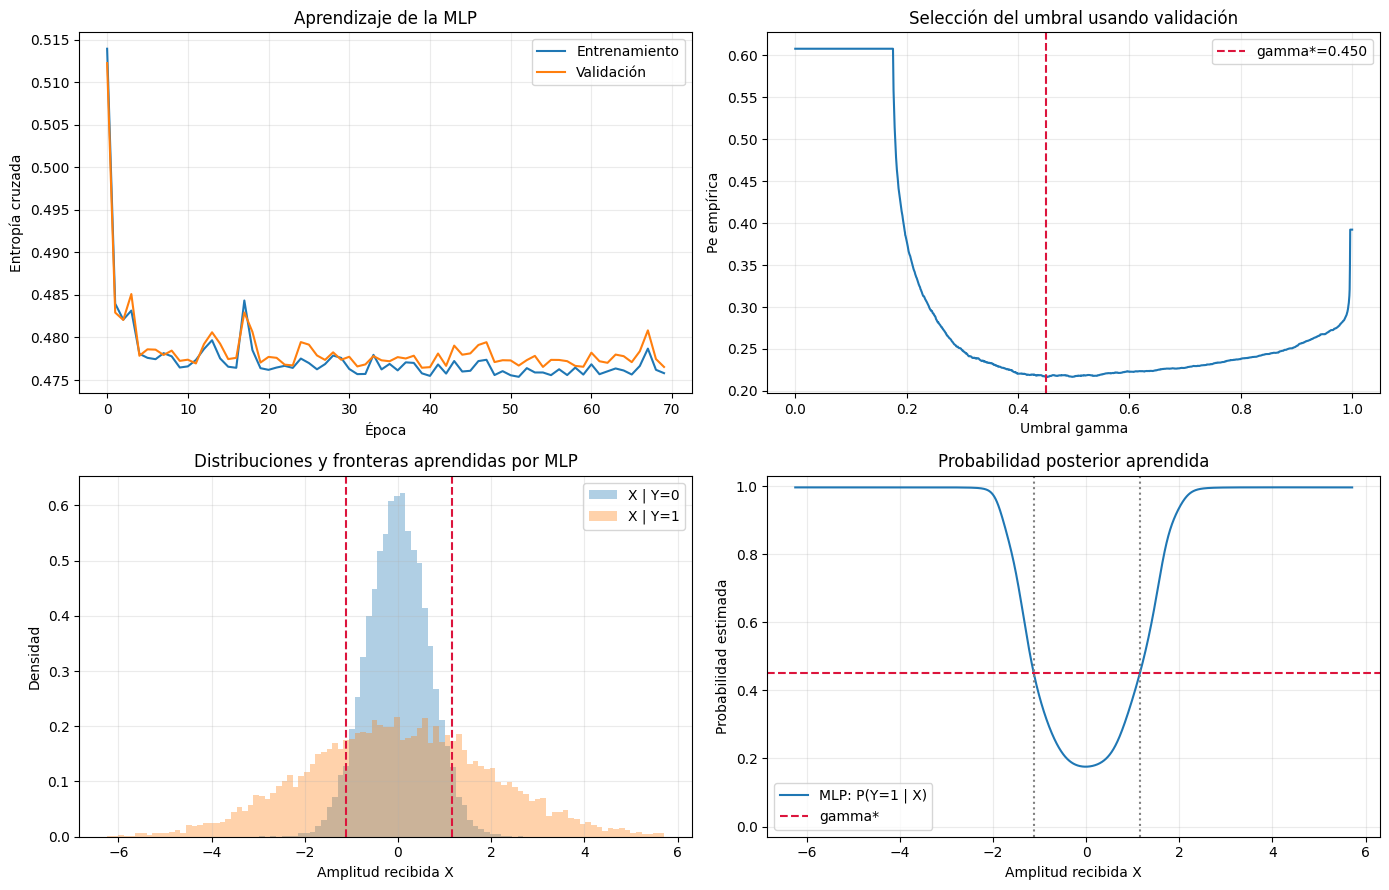

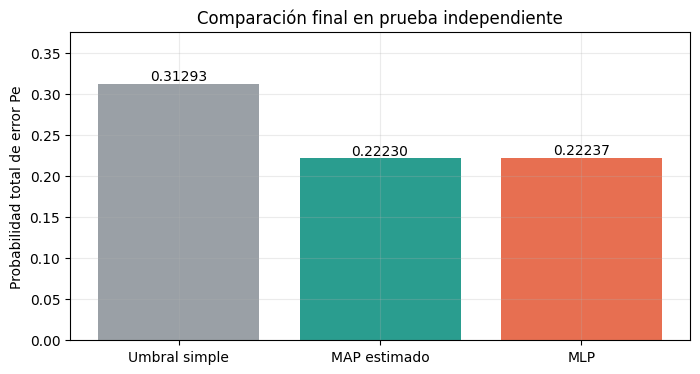

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0,0].plot(historial['train'], label='Entrenamiento')
ax[0,0].plot(historial['val'], label='Validación')
ax[0,0].set(title='Aprendizaje de la MLP', xlabel='Época', ylabel='Entropía cruzada')
ax[0,0].legend()

ax[0,1].plot(gammas, errores_val)
ax[0,1].axvline(gamma_opt, color='crimson', ls='--', label=f'gamma*={gamma_opt:.3f}')
ax[0,1].set(title='Selección del umbral usando validación', xlabel='Umbral gamma', ylabel='Pe empírica')
ax[0,1].legend()

bins = np.linspace(x_grid.min(), x_grid.max(), 100)
ax[1,0].hist(X_test[y_test.ravel()==0].ravel(), bins=bins, density=True, alpha=.35, label='X | Y=0')
ax[1,0].hist(X_test[y_test.ravel()==1].ravel(), bins=bins, density=True, alpha=.35, label='X | Y=1')
for f in fronteras_mlp:
    ax[1,0].axvline(f, color='crimson', ls='--')
ax[1,0].set(title='Distribuciones y fronteras aprendidas por MLP', xlabel='Amplitud recibida X', ylabel='Densidad')
ax[1,0].legend()

ax[1,1].plot(x_grid, prob_grid, label='MLP: P(Y=1 | X)')
ax[1,1].axhline(gamma_opt, color='crimson', ls='--', label='gamma*')
for f in fronteras_mlp:
    ax[1,1].axvline(f, color='gray', ls=':')
ax[1,1].set(title='Probabilidad posterior aprendida', xlabel='Amplitud recibida X', ylabel='Probabilidad estimada', ylim=(-.03, 1.03))
ax[1,1].legend()

plt.tight_layout()
plt.show()

nombres = ['Umbral simple', 'MAP estimado', 'MLP']
valores = [m_simple['Pe'], m_map['Pe'], m_mlp['Pe']]
plt.figure(figsize=(8,4))
barras = plt.bar(nombres, valores, color=['#9aa0a6', '#2a9d8f', '#e76f51'])
plt.ylabel('Probabilidad total de error Pe'); plt.title('Comparación final en prueba independiente')
plt.bar_label(barras, fmt='%.5f'); plt.ylim(0, max(valores)*1.2); plt.show()

## 8. Robustez frente a diferentes niveles y distribuciones de ruido

Ahora repetimos el procedimiento completo para distintos escenarios. En cada punto se generan conjuntos independientes, se reestiman los parámetros, se reentrena la MLP, se selecciona $\gamma^*$ mediante validación y finalmente se calcula $P_e$ sobre prueba.

Se estudian dos situaciones:

1. **Modelo gaussiano correcto:** MAP debería ser difícil de superar y la MLP debería aproximarlo.
2. **Distribuciones multimodales alternantes:** cada clase posee dos modos y una sola media/varianza no describe correctamente la frontera óptima.

In [ ]:
def datos_gaussianos_config(n, semilla, sigma0, sigma1, p1=0.40):
    r = np.random.default_rng(semilla)
    y = (r.random(n) < p1).astype(float)
    sigma = np.where(y == 0, sigma0, sigma1)
    x = sigma * r.standard_normal(n)
    return x.reshape(-1,1), y.reshape(-1,1)

def datos_multimodales(n, semilla, sigma, p1=0.50):
    r = np.random.default_rng(semilla)
    y = (r.random(n) < p1).astype(float)
    componente = r.integers(0, 2, n)
    # Regiones alternantes: clase 0 alrededor de -2 y +1; clase 1 alrededor de -1 y +2.
    centros0 = np.where(componente == 0, -2.0, 1.0)
    centros1 = np.where(componente == 0, -1.0, 2.0)
    centros = np.where(y == 0, centros0, centros1)
    x = centros + sigma * r.standard_normal(n)
    return x.reshape(-1,1), y.reshape(-1,1)

def evaluar_escenario(generador, valor_ruido, semilla_base):
    Xtr, ytr = generador(12000, semilla_base, valor_ruido)
    Xv, yv = generador(4000, semilla_base+1, valor_ruido)
    Xte, yte = generador(12000, semilla_base+2, valor_ruido)

    parametros = estimar_parametros(Xtr, ytr)
    media, std = Xtr.mean(axis=0), Xtr.std(axis=0)
    norm = lambda x: (x-media)/std
    red = MLPBinaria(capas=(1, 24, 24, 12, 1), semilla=semilla_base)
    entrenar(red, norm(Xtr), ytr, norm(Xv), yv, epocas=180, lote=256, lr=2e-3, paciencia=18)
    pv = red.predict_proba(norm(Xv))
    gamma, _, _, _ = buscar_umbral(yv, pv, n=1001)
    pred_mlp_local = red.predict_proba(norm(Xte)) >= gamma
    pred_map_local = predecir_map_estimado(Xte, parametros)
    mm = metricas_binarias(yte, pred_mlp_local)
    mp = metricas_binarias(yte, pred_map_local)

    grid = np.linspace(np.percentile(Xte, 0.05), np.percentile(Xte, 99.95), 2500).reshape(-1,1)
    fronteras = encontrar_fronteras(grid.ravel(), red.predict_proba(norm(grid)).ravel() >= gamma)
    return {'ruido': valor_ruido, 'Pe_MLP': mm['Pe'], 'Pe_MAP': mp['Pe'],
            'P10_MLP': mm['P(1|0)'], 'P01_MLP': mm['P(0|1)'],
            'gamma': gamma, 'fronteras_MLP': fronteras}

# Adaptadores para que ambos generadores compartan la misma interfaz.
gauss_sweep = lambda n, semilla, sigma1: datos_gaussianos_config(n, semilla, sigma0=0.65, sigma1=sigma1)
multi_sweep = lambda n, semilla, sigma: datos_multimodales(n, semilla, sigma=sigma)

resultados_gaussianos = [evaluar_escenario(gauss_sweep, s, 1000+10*i)
                         for i, s in enumerate([0.8, 1.2, 1.6, 2.0, 2.4])]
resultados_multimodales = [evaluar_escenario(multi_sweep, s, 2000+10*i)
                           for i, s in enumerate([0.15, 0.30, 0.50, 0.70, 0.90])]

def imprimir_resultados(titulo, resultados):
    print('\n' + titulo)
    print('ruido    Pe_MAP    Pe_MLP    P(1|0)_MLP  P(0|1)_MLP  fronteras MLP')
    for r in resultados:
        print(f'{r["ruido"]:5.2f}   {r["Pe_MAP"]:.5f}   {r["Pe_MLP"]:.5f}      '
              f'{r["P10_MLP"]:.5f}      {r["P01_MLP"]:.5f}     {np.round(r["fronteras_MLP"], 3)}')

imprimir_resultados('ESCENARIO A: GAUSSIANO', resultados_gaussianos)
imprimir_resultados('ESCENARIO B: MULTIMODAL ALTERNANTE', resultados_multimodales)

Entrenamiento terminado en 110 épocas. Mejor val_loss=0.666934
Entrenamiento terminado en 91 épocas. Mejor val_loss=0.591539
Entrenamiento terminado en 72 épocas. Mejor val_loss=0.526710
Entrenamiento terminado en 83 épocas. Mejor val_loss=0.470411
Entrenamiento terminado en 76 épocas. Mejor val_loss=0.432306
Entrenamiento terminado en 61 épocas. Mejor val_loss=0.002633
Entrenamiento terminado en 78 épocas. Mejor val_loss=0.123255
Entrenamiento terminado en 51 épocas. Mejor val_loss=0.384713
Entrenamiento terminado en 29 épocas. Mejor val_loss=0.538301
Entrenamiento terminado en 26 épocas. Mejor val_loss=0.610031

ESCENARIO A: GAUSSIANO
ruido    Pe_MAP    Pe_MLP    P(1|0)_MLP  P(0|1)_MLP  fronteras MLP
 0.80   0.38633   0.39750      0.14858      0.76676     [-0.989  0.915]
 1.20   0.30058   0.30108      0.09106      0.62142     [-1.103  1.093]
 1.60   0.25850   0.26033      0.06272      0.55914     [-1.233  1.257]
 2.00   0.21567   0.21775      0.05294      0.47133     [-1.185  1.27 ]


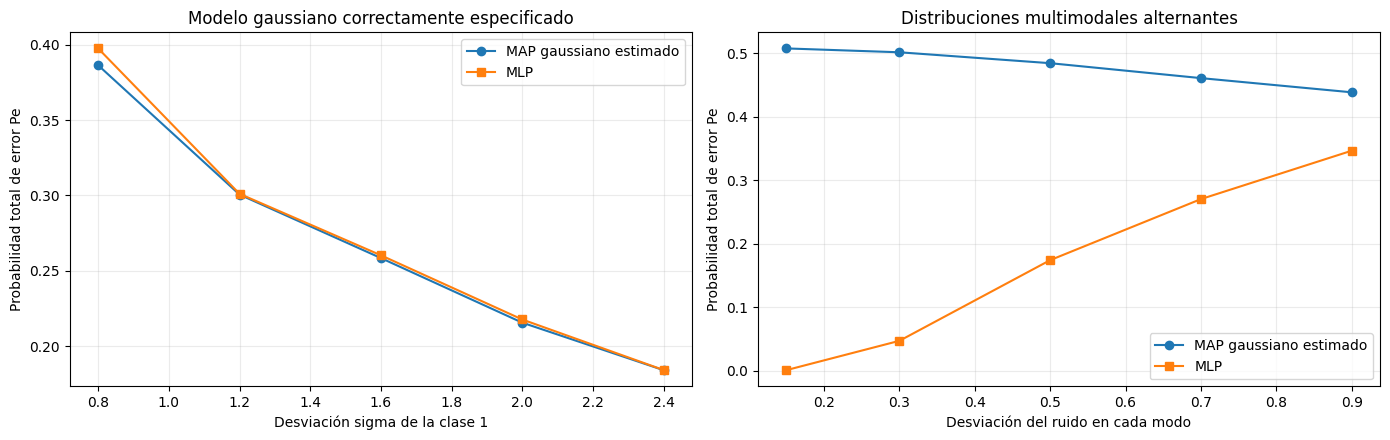

Ventaja de la MLP sobre MAP gaussiano en el caso multimodal (Pe_MAP - Pe_MLP):
sigma=0.15: 0.506417
sigma=0.30: 0.454167
sigma=0.50: 0.310000
sigma=0.70: 0.190417
sigma=0.90: 0.091917


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

for eje, resultados, titulo, xlabel in [
    (ax[0], resultados_gaussianos, 'Modelo gaussiano correctamente especificado', 'Desviación sigma de la clase 1'),
    (ax[1], resultados_multimodales, 'Distribuciones multimodales alternantes', 'Desviación del ruido en cada modo')]:
    ruido = [r['ruido'] for r in resultados]
    eje.plot(ruido, [r['Pe_MAP'] for r in resultados], 'o-', label='MAP gaussiano estimado')
    eje.plot(ruido, [r['Pe_MLP'] for r in resultados], 's-', label='MLP')
    eje.set(title=titulo, xlabel=xlabel, ylabel='Probabilidad total de error Pe')
    eje.legend()

plt.tight_layout(); plt.show()

ventajas = np.array([r['Pe_MAP']-r['Pe_MLP'] for r in resultados_multimodales])
print('Ventaja de la MLP sobre MAP gaussiano en el caso multimodal (Pe_MAP - Pe_MLP):')
for r, ventaja in zip(resultados_multimodales, ventajas):
    print(f'sigma={r["ruido"]:.2f}: {ventaja:.6f}')

## Interpretación del análisis de robustez

- En el escenario gaussiano, MAP y MLP deben producir errores cercanos. Esto confirma que la red aprende una regla consistente, pero no crea información adicional.
- En el escenario multimodal, la media y la varianza de cada clase no contienen toda la estructura. El MAP gaussiano impone una frontera demasiado sencilla, mientras que la MLP puede aprender varias regiones alternantes.
- En el escenario multimodal, aumentar la desviación de cada modo incrementa el solapamiento y eleva $P_e$.
- En el escenario gaussiano de medias iguales se mantiene fija $\sigma_0=0.65$ y se aumenta únicamente $\sigma_1$. Esta diferencia creciente entre varianzas hace las clases más distinguibles por su magnitud, por lo que $P_e$ puede disminuir aunque una clase sea más dispersa.
- La comparación justa siempre reentrena ambos métodos con datos del mismo escenario y conserva una prueba independiente.

## Resultados verificados de robustez

- En el modelo gaussiano, la diferencia entre MLP y MAP fue pequeña. Por ejemplo, para $\sigma_1=2.4$ se obtuvo aproximadamente $P_e^{MAP}=0.18417$ y $P_e^{MLP}=0.18425$.
- En el caso multimodal con $\sigma=0.15$, MAP gaussiano obtuvo aproximadamente $P_e=0.50733$, mientras que la MLP alcanzó $P_e=0.00092$.
- Para el caso multimodal más ruidoso, $\sigma=0.90$, MAP obtuvo aproximadamente $P_e=0.43825$ y la MLP $P_e=0.34633$.
- La MLP encontró tres fronteras cercanas a $-1.5$, $0$ y $1.5$, coherentes con las cuatro regiones alternantes generadas.

Estos resultados muestran que la principal ventaja de la MLP no consiste en superar un detector MAP correctamente especificado, sino en aprender fronteras complejas cuando la distribución real no puede resumirse adecuadamente mediante una sola media y varianza.

## 9. Benchmark final repetido: KDE vs. MAP vs. MLP vs. Bayes

Una sola ejecución no permite establecer robustez. Por ello repetimos tres escenarios representativos con semillas independientes y reportamos la media, desviación estándar e intervalo de confianza del 95% de $P_e$.

- **KDE:** estima densidades no paramétricas usando exclusivamente entrenamiento.
- **MAP gaussiano:** estima probabilidades, medias y varianzas usando entrenamiento, pero supone una gaussiana por clase.
- **MLP:** aprende la probabilidad posterior a partir de entrenamiento y selecciona $\gamma^*$ con validación.
- **Bayes óptimo:** conoce las distribuciones reales y representa la referencia teórica alcanzable. No es un método entrenado ni recibe el mismo nivel de información.

In [ ]:
def normal_pdf(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2)/(np.sqrt(2*np.pi)*sigma)

def kde_entrenar_1d(X, y, puntos=1400):
    x = X.ravel(); etiquetas = y.ravel().astype(int)
    margen = 0.15*(np.percentile(x, 99.9)-np.percentile(x, 0.1))
    limites = (np.percentile(x, 0.05)-margen, np.percentile(x, 99.95)+margen)
    bordes = np.linspace(*limites, puntos+1)
    centros = (bordes[:-1]+bordes[1:])/2
    dx = centros[1]-centros[0]
    densidades, priors = [], []
    for k in (0,1):
        valores = x[etiquetas==k]; priors.append(len(valores)/len(x))
        hist, _ = np.histogram(valores, bins=bordes, density=True)
        sigma = np.std(valores, ddof=1)
        h = max(1.06*sigma*len(valores)**(-1/5), 1.5*dx)  # Regla de Silverman
        radio = max(3, int(np.ceil(4*h/dx)))
        offsets = np.arange(-radio, radio+1)*dx
        kernel = np.exp(-0.5*(offsets/h)**2); kernel /= kernel.sum()
        densidades.append(np.convolve(hist, kernel, mode='same'))
    return centros, np.asarray(densidades), np.asarray(priors)

def kde_predecir(modelo, X):
    centros, densidades, priors = modelo
    x = X.ravel()
    d0 = np.interp(x, centros, densidades[0], left=1e-12, right=1e-12)*priors[0]
    d1 = np.interp(x, centros, densidades[1], left=1e-12, right=1e-12)*priors[1]
    return (d1>=d0).reshape(-1,1)

def bayes_gaussiano_real(X, sigma1, p1=0.40, sigma0=0.65):
    x=X.ravel(); p0=1-p1
    return (p1*normal_pdf(x,0,sigma1)>=p0*normal_pdf(x,0,sigma0)).reshape(-1,1)

def bayes_multimodal_real(X, sigma, p1=0.50):
    x=X.ravel(); p0=1-p1
    f0=0.5*normal_pdf(x,-2,sigma)+0.5*normal_pdf(x,1,sigma)
    f1=0.5*normal_pdf(x,-1,sigma)+0.5*normal_pdf(x,2,sigma)
    return (p1*f1>=p0*f0).reshape(-1,1)

def una_repeticion_benchmark(tipo, ruido, semilla):
    generador = gauss_sweep if tipo=='Gaussiano' else multi_sweep
    Xtr,ytr=generador(9000,semilla,ruido); Xv,yv=generador(3000,semilla+1,ruido)
    Xte,yte=generador(9000,semilla+2,ruido)
    parametros=estimar_parametros(Xtr,ytr)
    media,std=Xtr.mean(axis=0),Xtr.std(axis=0); norm=lambda x:(x-media)/std
    red=MLPBinaria(capas=(1,24,24,12,1),semilla=semilla)
    entrenar(red,norm(Xtr),ytr,norm(Xv),yv,epocas=150,lote=256,lr=2e-3,paciencia=15)
    gamma,_,_,_=buscar_umbral(yv,red.predict_proba(norm(Xv)),n=801)
    predicciones={
        'MLP': red.predict_proba(norm(Xte))>=gamma,
        'MAP gaussiano': predecir_map_estimado(Xte,parametros),
        'KDE': kde_predecir(kde_entrenar_1d(Xtr,ytr),Xte),
        'Bayes óptimo': bayes_gaussiano_real(Xte,ruido) if tipo=='Gaussiano' else bayes_multimodal_real(Xte,ruido)
    }
    salida=[]
    for detector,pred in predicciones.items():
        m=metricas_binarias(yte,pred)
        salida.append({'Escenario':f'{tipo}, ruido={ruido:.2f}','Detector':detector,
                       'P(1|0)':m['P(1|0)'],'P(0|1)':m['P(0|1)'],'Pe':m['Pe']})
    return salida

ESCENARIOS_FINALES=[('Gaussiano',2.0),('Multimodal',0.50),('Multimodal',0.90)]
REPETICIONES=8
benchmark=[]
for j,(tipo,ruido) in enumerate(ESCENARIOS_FINALES):
    for rep in range(REPETICIONES):
        benchmark.extend(una_repeticion_benchmark(tipo,ruido,5000+100*j+3*rep))

print(f'Benchmark terminado: {REPETICIONES} repeticiones independientes por escenario.')

Entrenamiento terminado en 67 épocas. Mejor val_loss=0.485252
Entrenamiento terminado en 66 épocas. Mejor val_loss=0.486930
Entrenamiento terminado en 56 épocas. Mejor val_loss=0.478153
Entrenamiento terminado en 55 épocas. Mejor val_loss=0.471972
Entrenamiento terminado en 70 épocas. Mejor val_loss=0.477578
Entrenamiento terminado en 39 épocas. Mejor val_loss=0.471733
Entrenamiento terminado en 46 épocas. Mejor val_loss=0.478298
Entrenamiento terminado en 66 épocas. Mejor val_loss=0.479516
Entrenamiento terminado en 26 épocas. Mejor val_loss=0.381690
Entrenamiento terminado en 43 épocas. Mejor val_loss=0.387318
Entrenamiento terminado en 83 épocas. Mejor val_loss=0.381163
Entrenamiento terminado en 43 épocas. Mejor val_loss=0.381018
Entrenamiento terminado en 21 épocas. Mejor val_loss=0.369406
Entrenamiento terminado en 55 épocas. Mejor val_loss=0.398550
Entrenamiento terminado en 57 épocas. Mejor val_loss=0.385621
Entrenamiento terminado en 68 épocas. Mejor val_loss=0.387670
Entrenam


TABLA FINAL: media ± desviación estándar; IC95% de Pe
Escenario                 Detector          P(1|0)          P(0|1)          Pe              IC95% Pe
Gaussiano, ruido=2.00     Bayes óptimo     0.0651±0.0038  0.4531±0.0117  0.2210±0.0052  [0.2174,0.2246]
Gaussiano, ruido=2.00     KDE              0.0614±0.0046  0.4591±0.0113  0.2212±0.0056  [0.2173,0.2251]
Gaussiano, ruido=2.00     MAP gaussiano    0.0660±0.0041  0.4513±0.0092  0.2208±0.0054  [0.2171,0.2245]
Gaussiano, ruido=2.00     MLP              0.0728±0.0144  0.4418±0.0234  0.2211±0.0048  [0.2178,0.2245]
Multimodal, ruido=0.50    Bayes óptimo     0.1721±0.0069  0.1727±0.0036  0.1724±0.0040  [0.1696,0.1752]
Multimodal, ruido=0.50    KDE              0.1684±0.0081  0.1770±0.0057  0.1727±0.0039  [0.1700,0.1754]
Multimodal, ruido=0.50    MAP gaussiano    0.4864±0.0087  0.4914±0.0046  0.4889±0.0058  [0.4849,0.4929]
Multimodal, ruido=0.50    MLP              0.1780±0.0205  0.1667±0.0199  0.1723±0.0041  [0.1694,0.1751]
Multimodal, 

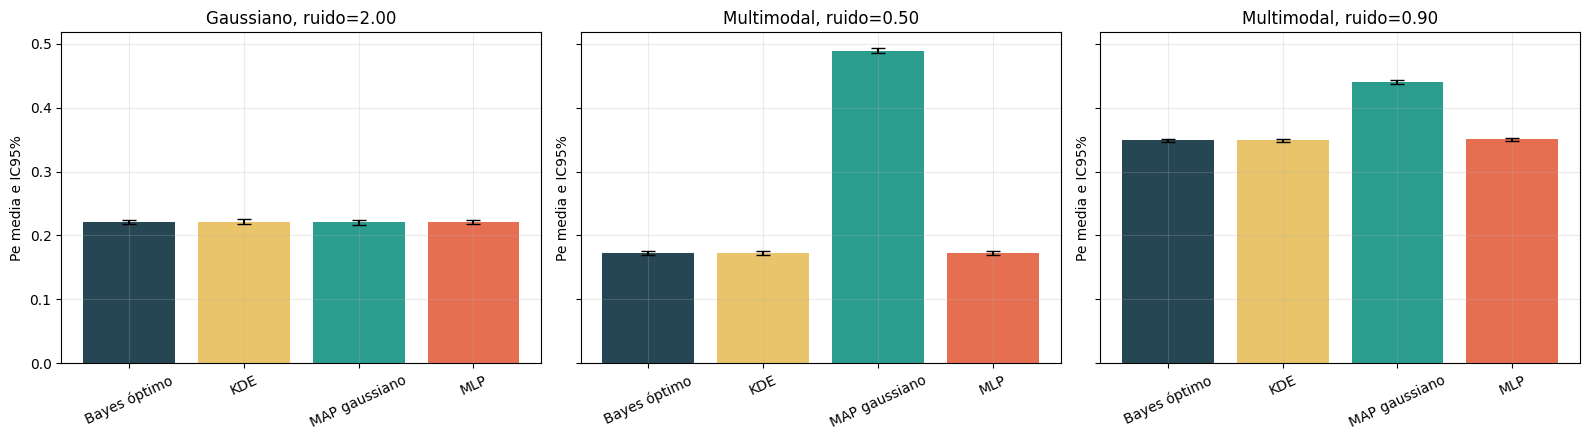

In [ ]:
def resumir_benchmark(filas):
    resumen=[]
    escenarios=list(dict.fromkeys(f['Escenario'] for f in filas))
    detectores=['Bayes óptimo','KDE','MAP gaussiano','MLP']
    for escenario in escenarios:
        for detector in detectores:
            grupo=[f for f in filas if f['Escenario']==escenario and f['Detector']==detector]
            fila={'Escenario':escenario,'Detector':detector}
            for metrica in ['P(1|0)','P(0|1)','Pe']:
                v=np.array([g[metrica] for g in grupo]); media=v.mean(); std=v.std(ddof=1)
                sem=std/np.sqrt(len(v)); margen=1.96*sem
                fila[metrica]=media; fila[metrica+'_std']=std
                fila[metrica+'_IC95']=(media-margen,media+margen)
            resumen.append(fila)
    return resumen

resumen_final=resumir_benchmark(benchmark)
print('\nTABLA FINAL: media ± desviación estándar; IC95% de Pe')
print('Escenario                 Detector          P(1|0)          P(0|1)          Pe              IC95% Pe')
for r in resumen_final:
    ic=r['Pe_IC95']
    print(f'{r["Escenario"]:<25} {r["Detector"]:<16} '
          f'{r["P(1|0)"]:.4f}±{r["P(1|0)_std"]:.4f}  '
          f'{r["P(0|1)"]:.4f}±{r["P(0|1)_std"]:.4f}  '
          f'{r["Pe"]:.4f}±{r["Pe_std"]:.4f}  [{ic[0]:.4f},{ic[1]:.4f}]')

fig,axes=plt.subplots(1,3,figsize=(16,4.5),sharey=True)
colores={'Bayes óptimo':'#264653','KDE':'#e9c46a','MAP gaussiano':'#2a9d8f','MLP':'#e76f51'}
for ax,(tipo,ruido) in zip(axes,ESCENARIOS_FINALES):
    escenario=f'{tipo}, ruido={ruido:.2f}'
    grupo=[r for r in resumen_final if r['Escenario']==escenario]
    nombres=[r['Detector'] for r in grupo]; medias=[r['Pe'] for r in grupo]
    errores=[1.96*r['Pe_std']/np.sqrt(REPETICIONES) for r in grupo]
    ax.bar(nombres,medias,yerr=errores,capsize=5,color=[colores[n] for n in nombres])
    ax.set_title(escenario); ax.set_ylabel('Pe media e IC95%'); ax.tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.show()

## Criterio de finalización

El trabajo puede considerarse concluido cuando las ejecuciones repetidas confirmen que:

1. MLP, KDE y MAP se aproximan a Bayes cuando el modelo gaussiano es correcto.
2. MLP y KDE superan de manera estable al MAP gaussiano en distribuciones multimodales.
3. La MLP permanece cerca de Bayes y sus resultados presentan baja variabilidad entre semillas.
4. Las conclusiones se basan en prueba independiente y no únicamente en entrenamiento o validación.

## Resultados finales verificados

Cada valor corresponde a la media de ocho ejecuciones independientes. El intervalo mostrado corresponde al IC del 95% para $P_e$.

| Escenario | Detector | $P(1\mid0)$ | $P(0\mid1)$ | $P_e$ medio | IC 95% de $P_e$ |
|---|---:|---:|---:|---:|---:|
| Gaussiano, $\sigma_1=2.00$ | Bayes óptimo | 0.06509 | 0.45312 | 0.22097 | [0.21737, 0.22458] |
| Gaussiano, $\sigma_1=2.00$ | KDE | 0.06139 | 0.45914 | 0.22121 | [0.21731, 0.22510] |
| Gaussiano, $\sigma_1=2.00$ | MAP gaussiano | 0.06596 | 0.45135 | 0.22081 | [0.21707, 0.22454] |
| Gaussiano, $\sigma_1=2.00$ | MLP | 0.07280 | 0.44184 | 0.22113 | [0.21779, 0.22446] |
| Multimodal, $\sigma=0.50$ | Bayes óptimo | 0.17214 | 0.17269 | 0.17242 | [0.16962, 0.17521] |
| Multimodal, $\sigma=0.50$ | KDE | 0.16840 | 0.17702 | 0.17272 | [0.17002, 0.17542] |
| Multimodal, $\sigma=0.50$ | MAP gaussiano | 0.48637 | 0.49141 | 0.48889 | [0.48486, 0.49292] |
| Multimodal, $\sigma=0.50$ | MLP | 0.17805 | 0.16669 | 0.17229 | [0.16944, 0.17515] |
| Multimodal, $\sigma=0.90$ | Bayes óptimo | 0.34899 | 0.34797 | 0.34849 | [0.34593, 0.35104] |
| Multimodal, $\sigma=0.90$ | KDE | 0.34860 | 0.34854 | 0.34850 | [0.34618, 0.35082] |
| Multimodal, $\sigma=0.90$ | MAP gaussiano | 0.44256 | 0.43799 | 0.44022 | [0.43669, 0.44376] |
| Multimodal, $\sigma=0.90$ | MLP | 0.34603 | 0.35501 | 0.35043 | [0.34801, 0.35286] |

### Conclusiones definitivas

1. En datos gaussianos correctamente modelados, los intervalos de confianza de Bayes, KDE, MAP y MLP se superponen ampliamente. La MLP aprende una regla prácticamente óptima sin conocer los parámetros reales.
2. Para la distribución multimodal con $\sigma=0.50$, la MLP reduce el error medio de MAP gaussiano desde 0.48889 hasta 0.17229 y alcanza el nivel de Bayes.
3. Para la distribución multimodal con $\sigma=0.90$, la MLP conserva una ventaja clara: 0.35043 frente a 0.44022 de MAP gaussiano.
4. KDE también se aproxima a Bayes en una dimensión. La MLP adquiere mayor valor cuando se incorporan múltiples características, donde KDE se vuelve más costoso por la maldición de la dimensionalidad.
5. Las conclusiones son consistentes entre semillas independientes y se calcularon sobre conjuntos de prueba que no participaron en el entrenamiento ni en la selección del umbral.

**Conclusión general:** el detector MLP implementado cumple el objetivo, estima etiquetas sin conocer previamente probabilidades, medias o varianzas, calcula las probabilidades de error solicitadas y aprende fronteras no lineales cercanas al detector Bayesiano.

## 10. Generalización ante ruido desconocido sin reentrenamiento

Los experimentos anteriores reentrenan la red para cada escenario y demuestran capacidad de aprendizaje. Para evaluar robustez real frente a cambios del canal, ahora se entrenan dos redes una sola vez:

1. **MLP fija:** entrenada solamente con ruido multimodal $\sigma=0.50$.
2. **MLP mezcla:** entrenada con niveles de ruido aleatorios uniformes entre $\sigma=0.15$ y $\sigma=0.90$.

Después, ambas redes se evalúan sin reentrenamiento para diferentes niveles de ruido. El umbral de cada red también permanece fijo y se selecciona únicamente con su validación original.

In [ ]:
def datos_multimodales_mezcla(n, semilla, sigma_min=0.15, sigma_max=0.90):
    r=np.random.default_rng(semilla)
    y=(r.random(n)<0.50).astype(float); componente=r.integers(0,2,n)
    centros0=np.where(componente==0,-2.0,1.0); centros1=np.where(componente==0,-1.0,2.0)
    centros=np.where(y==0,centros0,centros1)
    sigmas=r.uniform(sigma_min,sigma_max,n)
    x=centros+sigmas*r.standard_normal(n)
    return x.reshape(-1,1),y.reshape(-1,1)

def entrenar_detector_generalizacion(tipo, semilla):
    if tipo=='Fija sigma=0.50':
        Xtr,ytr=datos_multimodales(16000,semilla,0.50); Xv,yv=datos_multimodales(5000,semilla+1,0.50)
    else:
        Xtr,ytr=datos_multimodales_mezcla(16000,semilla); Xv,yv=datos_multimodales_mezcla(5000,semilla+1)
    media,std=Xtr.mean(axis=0),Xtr.std(axis=0); norm=lambda x:(x-media)/std
    red=MLPBinaria(capas=(1,32,32,16,1),semilla=semilla)
    entrenar(red,norm(Xtr),ytr,norm(Xv),yv,epocas=180,lote=256,lr=2e-3,paciencia=20)
    gamma,_,_,_=buscar_umbral(yv,red.predict_proba(norm(Xv)),n=1001)
    return red,norm,gamma

NIVELES_GENERALIZACION=[0.15,0.30,0.50,0.70,0.90]
REPETICIONES_GENERALIZACION=5
resultados_generalizacion=[]
for rep in range(REPETICIONES_GENERALIZACION):
    modelos={tipo:entrenar_detector_generalizacion(tipo,7000+20*rep+i)
             for i,tipo in enumerate(['Fija sigma=0.50','Mezcla sigma=[0.15,0.90]'])}
    for sigma in NIVELES_GENERALIZACION:
        Xte,yte=datos_multimodales(15000,8000+100*rep+int(100*sigma),sigma)
        for tipo,(red,norm,gamma) in modelos.items():
            pred=red.predict_proba(norm(Xte))>=gamma
            m=metricas_binarias(yte,pred)
            resultados_generalizacion.append({'Modelo':tipo,'sigma_prueba':sigma,
                'Pe':m['Pe'],'P(1|0)':m['P(1|0)'],'P(0|1)':m['P(0|1)']})

def resumen_generalizacion(filas):
    salida=[]
    for modelo in ['Fija sigma=0.50','Mezcla sigma=[0.15,0.90]']:
        for sigma in NIVELES_GENERALIZACION:
            g=[f for f in filas if f['Modelo']==modelo and f['sigma_prueba']==sigma]
            v=np.array([f['Pe'] for f in g]); media=v.mean(); std=v.std(ddof=1)
            salida.append({'Modelo':modelo,'sigma_prueba':sigma,'Pe':media,'std':std,
                           'IC95':(media-1.96*std/np.sqrt(len(v)),media+1.96*std/np.sqrt(len(v)))})
    return salida

resumen_gen=resumen_generalizacion(resultados_generalizacion)
print('GENERALIZACIÓN SIN REENTRENAMIENTO: Pe media ± desviación estándar')
for r in resumen_gen:
    print(f'{r["Modelo"]:<27} sigma_prueba={r["sigma_prueba"]:.2f}: '
          f'Pe={r["Pe"]:.5f} ± {r["std"]:.5f}; IC95={np.round(r["IC95"],5)}')

Entrenamiento terminado en 61 épocas. Mejor val_loss=0.393167
Entrenamiento terminado en 80 épocas. Mejor val_loss=0.429367
Entrenamiento terminado en 47 épocas. Mejor val_loss=0.393924
Entrenamiento terminado en 66 épocas. Mejor val_loss=0.408811
Entrenamiento terminado en 57 épocas. Mejor val_loss=0.375691
Entrenamiento terminado en 93 épocas. Mejor val_loss=0.432660
Entrenamiento terminado en 52 épocas. Mejor val_loss=0.381647
Entrenamiento terminado en 52 épocas. Mejor val_loss=0.420212
Entrenamiento terminado en 77 épocas. Mejor val_loss=0.374282
Entrenamiento terminado en 60 épocas. Mejor val_loss=0.424858
GENERALIZACIÓN SIN REENTRENAMIENTO: Pe media ± desviación estándar
Fija sigma=0.50             sigma_prueba=0.15: Pe=0.00064 ± 0.00026; IC95=[0.00042 0.00086]
Fija sigma=0.50             sigma_prueba=0.30: Pe=0.04797 ± 0.00200; IC95=[0.04622 0.04973]
Fija sigma=0.50             sigma_prueba=0.50: Pe=0.17388 ± 0.00360; IC95=[0.17073 0.17703]
Fija sigma=0.50             sigma_pru

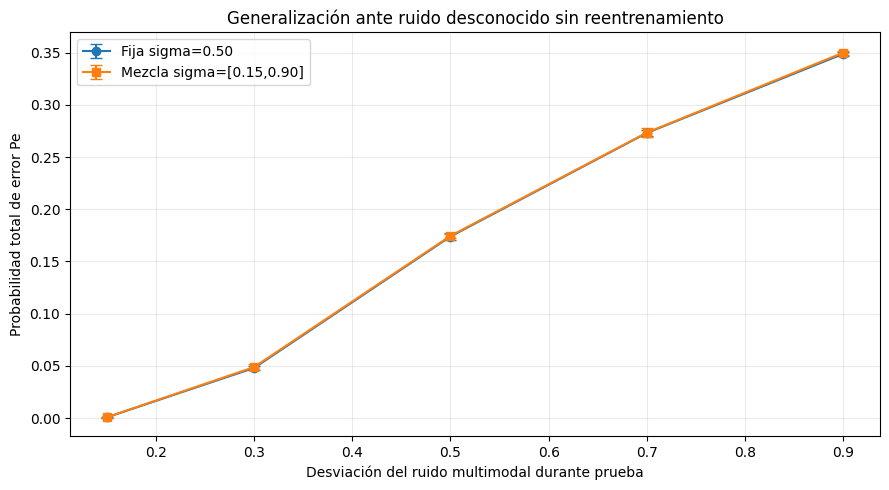

In [ ]:
plt.figure(figsize=(9,5))
for modelo,marcador in [('Fija sigma=0.50','o'),('Mezcla sigma=[0.15,0.90]','s')]:
    g=[r for r in resumen_gen if r['Modelo']==modelo]
    x=[r['sigma_prueba'] for r in g]; y=[r['Pe'] for r in g]
    err=[1.96*r['std']/np.sqrt(REPETICIONES_GENERALIZACION) for r in g]
    plt.errorbar(x,y,yerr=err,marker=marcador,capsize=4,label=modelo)
plt.xlabel('Desviación del ruido multimodal durante prueba')
plt.ylabel('Probabilidad total de error Pe')
plt.title('Generalización ante ruido desconocido sin reentrenamiento')
plt.legend(); plt.tight_layout(); plt.show()

### Interpretación de generalización

- La MLP fija permite medir cuánto se degrada una red cuando el canal cambia respecto al escenario usado durante entrenamiento.
- La MLP entrenada con mezcla de ruidos busca aprender una regla más estable para todo el intervalo y representa una estrategia de aumento de datos.
- Ninguna de las dos redes se reentrena durante la prueba. Por tanto, este experimento sí mide generalización frente a niveles de ruido no observados como escenarios individuales durante el ajuste.
- En este modelo multimodal, las fronteras Bayes aproximadamente ubicadas en $-1.5$, $0$ y $1.5$ permanecen casi invariantes al modificar una desviación común para todos los modos. Esto explica por qué la red fija generaliza tan bien entre niveles.

### Resultados verificados sin reentrenamiento

| $\sigma$ de prueba | MLP fija, $P_e$ | MLP mezcla, $P_e$ |
|---:|---:|---:|
| 0.15 | 0.00064 | 0.00072 |
| 0.30 | 0.04797 | 0.04881 |
| 0.50 | 0.17388 | 0.17449 |
| 0.70 | 0.27305 | 0.27337 |
| 0.90 | 0.34884 | 0.34999 |

La cercanía entre ambas redes demuestra que una MLP entrenada en un único nivel intermedio puede conservar una regla de decisión adecuada cuando cambia la dispersión, siempre que la geometría fundamental de las clases permanezca estable.

## Interpretación esperada

- El **umbral simple sobre $X$** falla en este escenario porque la clase de mayor varianza aparece en ambos extremos de la distribución.
- El **detector MAP estimado** encuentra dos regiones de decisión usando los parámetros aprendidos de entrenamiento.
- La **MLP** debe aprender una probabilidad posterior con forma de U y producir dos fronteras sobre $X$, aunque use un único umbral sobre su salida.
- Una MLP no puede superar sistemáticamente al detector MAP cuando el modelo gaussiano asumido es exactamente correcto y sus parámetros son conocidos. Su ventaja aparece cuando las distribuciones reales son desconocidas, no gaussianas o más complejas.

La prueba independiente y los intervalos de confianza permiten afirmar si una diferencia observada es realista y no solamente producto del azar.